In [7]:
import pywdf
import numpy as np 

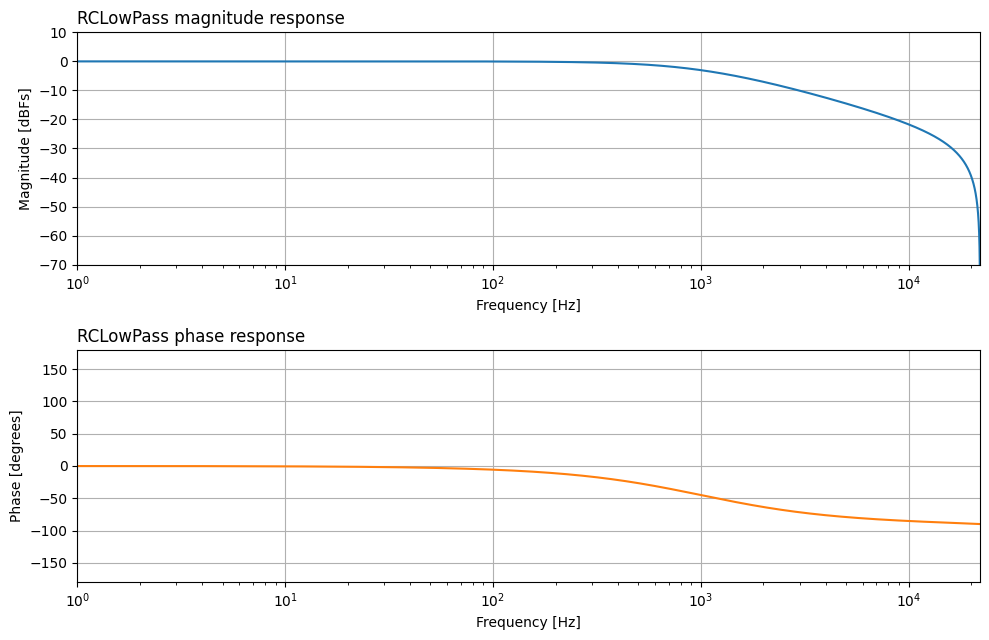

In [8]:
from pywdf.examples.rclowpass import RCLowPass
SAMPLERATE = 44100
cutoff = 1000 # Hz

rc_lpf_1st = RCLowPass(SAMPLERATE, cutoff)
rc_lpf_1st.plot_freqz()

In [9]:
from pywdf.core.wdf import *
from pywdf.core.circuit import Circuit


class RCHighPass(Circuit):
    def __init__(self, sample_rate: int, cutoff: float) -> None:

        self.fs = sample_rate
        self.cutoff = cutoff

        self.C = 1e-6
        self.R = 1.0 / (2 * np.pi * self.C * self.cutoff)

        self.R1 = Resistor(self.R)
        self.C1 = Capacitor(self.C, self.fs)

        self.S1 = SeriesAdaptor(self.C1, self.R1)
        self.I1 = PolarityInverter(self.S1)
        self.Vs = IdealVoltageSource(self.I1)

        super().__init__(self.Vs, self.Vs, self.R1)

    def set_cutoff(self, new_cutoff: float):
        if self.cutoff != new_cutoff:
            self.cutoff = new_cutoff
            self.R = 1.0 / (2 * np.pi * self.C * self.cutoff)
            self.R1.set_resistance(self.R)


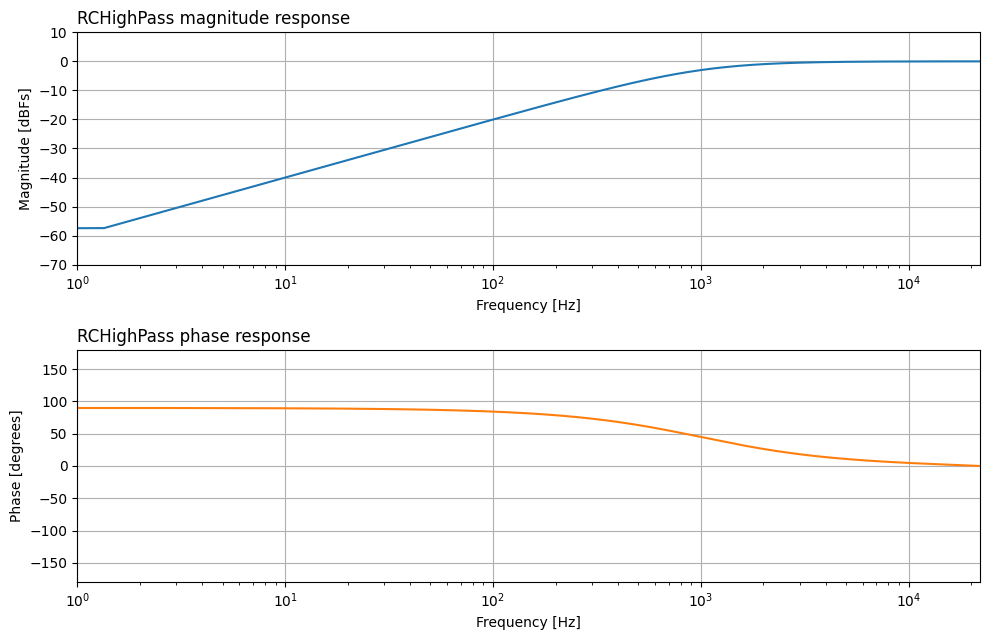

In [10]:
rc_hpf_1st = RCHighPass(SAMPLERATE, cutoff)
rc_hpf_1st.plot_freqz()

In [ ]:
class RC2ndOrderHighPass(Circuit):
    """
    RC 2nd-order high-pass filter using WDFs.
    """
    def __init__(self, sample_rate: int, cutoff: float, C: float = 1e-6) -> None:
        self.fs      = sample_rate
        self.cutoff  = cutoff
        self.C       = C

        # factor Butterworth de 2.º-orden
        self.k = np.sqrt(np.sqrt(2) + 1)

        # resistencia ajustada por k
        self.R = self.k / (2 * np.pi * self.C * self.cutoff)

        # elementos WDF
        self.R1 = Resistor(self.R)
        self.C1 = Capacitor(self.C, self.fs)

        self.R2 = Resistor(self.R)
        self.C2 = Capacitor(self.C, self.fs)

        self.S1 = SeriesAdaptor(self.C2, self.R2)
        self.P1 = ParallelAdaptor(self.R1, self.S1)

        self.S2 = SeriesAdaptor(self.C1, self.P1)
        self.I1 = PolarityInverter(self.S2)
        self.Vs = IdealVoltageSource(self.I1)

        super().__init__(self.Vs, self.Vs, self.R2)

    def set_cutoff(self, new_cutoff: float):
        if self.cutoff != new_cutoff:
            self.cutoff = new_cutoff
            self.R = self.k / (2 * np.pi * self.C * self.cutoff)
            self.R1.set_resistance(self.R)
            self.R2.set_resistance(self.R)


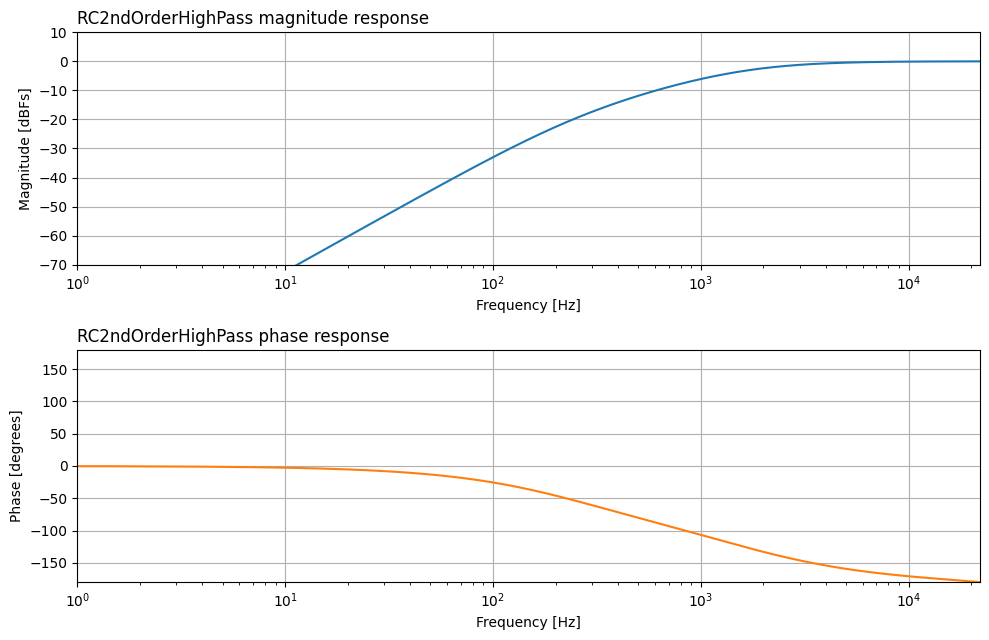

In [12]:
rc_hpf_2nd = RC2ndOrderHighPass(SAMPLERATE, cutoff)
rc_hpf_2nd.set_cutoff(cutoff)
rc_hpf_2nd.plot_freqz()